# Data Preprocessing

**Project:** R2 - Bike Sharing Demand

**Team:** Angelina Bautista & Molly Scally




## Table of Contents
1. Setup & Load Data
2. Drop Rows with Missing TARGET 
3. Simple Cleaning
4. Train-Test Split
5. Handle Missing Values
6. Handle Outliers
7. Key Findings Summary

---

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# settings
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("✓ Libraries loaded!")

✓ Libraries loaded!


## 1. Setup & Load Data

- How many rows and columns does your raw dataset have?
- Which column is your target variable?
- What issues from Notebook 01 will you address in this notebook?

In [2]:
# load data
df = pd.read_csv('../data/raw/hour.csv')
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


In [3]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
df.shape

(17379, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [6]:
print(f'The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')

The dataset contains 17379 rows and 17 columns.


### Observations

1. The raw dataset contains **17,379 rows** (observations) and **17 columns**, as indicated by the shape. To reiterate, the dataset contains data over a 2-year period, from the full years 2011-2012. The rows correspond to an hour of each day. Having a total of 17,379 hours means it does not account for 165 hours (17,520 + 24 for 2012's leap day = 17,544).

2. The column `cnt`, the total amount of `casual` and `registered` bikes, is the target variable. 

3. Issues addressed from our EDA notebook include:
    - reencoding differently pre-encoded features
    - considering transformations working with outliers
    - taking special care with multicollinearity 

## 2. Drop Rows with Missing Target

**Questions to answer:**
- How many rows had a missing target value?
- What percentage of the dataset does that represent?
- How many rows remain after dropping?

In [7]:
# check for missing TARGET value
missing_target = df['cnt'].isna().sum()
total_rows = len(df)

print("Missing target rows:", missing_target)

Missing target rows: 0


In [8]:
# percent of missing TARGET value
percent_missing = (missing_target / total_rows) * 100
print(f"Percentage missing: {percent_missing:.2f}%")

Percentage missing: 0.00%


In [9]:
# remaining rows
df = df.dropna(subset=['cnt'])
remaining_rows = len(df)

print("Remaining rows:", remaining_rows)

Remaining rows: 17379


We can verify these findings by checking the missing value counts of each feature.

In [10]:
print(df.isnull().sum())
print(f"\n Total rows: {len(df)}")

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

 Total rows: 17379


### Observations

1. 0 rows from the raw dataset have a missing TARGET value.
2. This represents 0.00% of the dataset (0 out of 17,379 rows).
3. 17,379 rows remain, which is the original amount of rows.

## 3. Simple Cleaning (Before Split)

These operations are safe before splitting because they do not use statistics.

- Remove duplicate rows
- Drop any data-leakage columns — features that would not be known at the time a prediction is made 
- Remove impossible values 

In [11]:
df_clean = df.copy()

In [12]:
# find duplicates
duplicates = df_clean.duplicated().sum()
print(f'Duplicate rows found: {duplicates}')

Duplicate rows found: 0


In [13]:
# remove any duplicate rows
if duplicates>0:
    df_clean = df_clean.drop_duplicates()
    print(f'removed {duplicates} duplicated rows')
else:
    print('No duplicates removed.')

No duplicates removed.


In [14]:
# check for impossible values
positive_col = df_clean.select_dtypes(include=['int', 'float'])

for col in positive_col:
    # check if negative values
    neg_count = (df_clean[col]<0).sum()

    if neg_count:
        print(f'{col}: has negative values')
        print(f'Samples: ')
        print(f'{df[df_clean[col]<0].head(3)}')

if neg_count == 0:
    print('No negative values found.')

No negative values found.


In [15]:
# convert date
df['dteday'] = pd.to_datetime(df['dteday']) 
print('Column converted.')

Column converted.


In [16]:
df_clean = df.drop(columns={'casual', 'registered', 'instant', 'dteday'})
print('Columns removed.')

Columns removed.


In [17]:
cat_cols = ['season', 'yr', 'mnth', 'hr', 'holiday', 
            'weekday', 'workingday', 'weathersit']

df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=False)

In [18]:
print(df_clean.columns)

Index(['temp', 'atemp', 'hum', 'windspeed', 'cnt', 'season_1', 'season_2',
       'season_3', 'season_4', 'yr_0', 'yr_1', 'mnth_1', 'mnth_2', 'mnth_3',
       'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10',
       'mnth_11', 'mnth_12', 'hr_0', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5',
       'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_11', 'hr_12', 'hr_13',
       'hr_14', 'hr_15', 'hr_16', 'hr_17', 'hr_18', 'hr_19', 'hr_20', 'hr_21',
       'hr_22', 'hr_23', 'holiday_0', 'holiday_1', 'weekday_0', 'weekday_1',
       'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6',
       'workingday_0', 'workingday_1', 'weathersit_1', 'weathersit_2',
       'weathersit_3', 'weathersit_4'],
      dtype='object')


In [19]:
df_clean.describe()

,temp,atemp,hum,windspeed,cnt
count,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,0.496987,0.475775,0.627229,0.190098,189.463088
std,0.192556,0.171850,0.192930,0.122340,181.387599
min,0.020000,0.000000,0.000000,0.000000,1.000000
25%,0.340000,0.333300,0.480000,0.104500,40.000000
50%,0.500000,0.484800,0.630000,0.194000,142.000000
75%,0.660000,0.621200,0.780000,0.253700,281.000000
max,1.000000,1.000000,1.000000,0.850700,977.000000


In [20]:
print(f"\nDataset shape originally: {df.shape}")
print(f"\nDataset shape after all pre-split cleaning: {df_clean.shape}")


Dataset shape originally: (17379, 17)

Dataset shape after all pre-split cleaning: (17379, 62)


### Observations

1. 0 duplicate rows were found, so none were dropped.
2. Dropped features:
   - `casual` and `registered` due to data leakage. These features are highly correlated to the target meaning it can artificially inflate model performance.
   - `instant` due to its lack of predictive power and its simply a unique identifier for each hour, and doesn't provide information about the environment, time of day/year, etc.
   - `dteday` because we are not modeling the bike rental count as a time series. We are just regressing the variables on bike count, to discover relationships between it and these variables, in a general sense. Also, we already have columns for the hour of the day, month, season etc., so the aspects about time that we care about most will still remain for the problem.
3. The summary statistics show positive, realistic ranges for the features in `positive_col`, resulting in no rows being dropped for impossible values.
4. Applied one-hot encoding on pre-encoded features: `season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`
   - Since some features were multi-level, this created an influx of features, bringing it from originally 17 to 62 variables. 

## 4. Train-Test Split

- Print the shapes of `X_train`, `X_test`, `y_train`, and `y_test`.
- How many rows are in the training set? The test set?

In [21]:
# create feature matrix and target array
X = df_clean.drop('cnt',axis=1)
y = df_clean['cnt']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (17379, 61)
Target (y) shape: (17379,)


In [22]:
X

,temp,atemp,hum,windspeed,season_1,season_2,season_3,season_4,yr_0,yr_1,mnth_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,hr_0,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23,holiday_0,holiday_1,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3,weathersit_4
0,0.24,0.2879,0.81,0.0000,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False
1,0.22,0.2727,0.80,0.0000,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False
2,0.22,0.2727,0.80,0.0000,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False
3,0.24,0.2879,0.75,0.0000,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False
4,0.24,0.2879,0.75,0.0000,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,0.26,0.2576,0.60,0.1642,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False
17375,0.26,0.2576,0.60,0.1642,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False
17376,0.26,0.2576,0.60,0.1642,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,True,True,False,False,False
17377,0.26,0.2727,0.56,0.1343,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,True,False,False,False


In [23]:
y

0         16
1         40
2         32
3         13
4          1
        ... 
17374    119
17375     89
17376     90
17377     61
17378     49
Name: cnt, Length: 17379, dtype: int64

In [24]:
# split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4950)

print("X train shape:", X_train.shape)
print("X test shape:", X_test.shape)

print("y train shape:", y_train.shape)
print("y test shape:", y_test.shape)

print(f'Training:{X_train.shape[0]: ,} samples')
print(f'Ttest:{X_test.shape[0]: ,} samples')

X train shape: (13903, 61)
X test shape: (3476, 61)
y train shape: (13903,)
y test shape: (3476,)
Training: 13,903 samples
Ttest: 3,476 samples


In [25]:
X_train

,temp,atemp,hum,windspeed,season_1,season_2,season_3,season_4,yr_0,yr_1,mnth_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,hr_0,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23,holiday_0,holiday_1,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3,weathersit_4
15346,0.60,0.6212,0.46,0.4179,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False
6195,0.60,0.5606,0.83,0.1045,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False
6664,0.44,0.4394,0.94,0.0000,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,False
9537,0.30,0.3182,0.49,0.0000,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False
9674,0.12,0.1212,0.50,0.2239,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11300,0.52,0.5000,0.77,0.2239,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False
3652,0.58,0.5455,0.88,0.1045,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,True,False,False,False
7316,0.42,0.4242,0.58,0.0896,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,False
11914,0.72,0.6667,0.48,0.1045,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False,False


In [26]:
X_test

,temp,atemp,hum,windspeed,season_1,season_2,season_3,season_4,yr_0,yr_1,mnth_1,mnth_2,mnth_3,mnth_4,mnth_5,mnth_6,mnth_7,mnth_8,mnth_9,mnth_10,mnth_11,mnth_12,hr_0,hr_1,hr_2,hr_3,hr_4,hr_5,hr_6,hr_7,hr_8,hr_9,hr_10,hr_11,hr_12,hr_13,hr_14,hr_15,hr_16,hr_17,hr_18,hr_19,hr_20,hr_21,hr_22,hr_23,holiday_0,holiday_1,weekday_0,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_0,workingday_1,weathersit_1,weathersit_2,weathersit_3,weathersit_4
16537,0.34,0.3636,0.53,0.0000,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,True,False,False,False
11574,0.58,0.5455,0.81,0.1343,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,True,False,False
12050,0.56,0.5303,0.88,0.1045,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,False,False,True,False
6787,0.52,0.5000,0.48,0.2985,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,True,False,False,False
8209,0.36,0.3485,0.40,0.1940,False,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1108,0.54,0.5152,0.10,0.2537,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,True,True,False,False,False
582,0.22,0.1970,0.93,0.3284,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False
15908,0.42,0.4242,0.50,0.2239,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,True,False,False,False
14308,0.72,0.6667,0.58,0.0000,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,True,False,True,False,False


### Observations

- The data is split using an 80/20 split with `test_size` = 0.2 and `random_state` = 4950.
- This produces:
    - a shape of (13903 rows × 14 columns) for the training set
    - a shape of (3476 rows × 14 columns) for the test set
    - and 1 target variable in both the training and test set
- Since this is a regression task, we applied a standard train-test split without stratification, as the target variable’s range and distribution appear consistent between the training and testing sets based on the earlier EDA.

### 5. Handle Missing Values

Identify missing values in the training set first, then apply the chosen strategy to both the training and test sets. All statistics (mean, median, mode) must be calculated from training data only, then applied to both sets.

In [27]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13903 entries, 15346 to 5997
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temp          13903 non-null  float64
 1   atemp         13903 non-null  float64
 2   hum           13903 non-null  float64
 3   windspeed     13903 non-null  float64
 4   season_1      13903 non-null  bool   
 5   season_2      13903 non-null  bool   
 6   season_3      13903 non-null  bool   
 7   season_4      13903 non-null  bool   
 8   yr_0          13903 non-null  bool   
 9   yr_1          13903 non-null  bool   
 10  mnth_1        13903 non-null  bool   
 11  mnth_2        13903 non-null  bool   
 12  mnth_3        13903 non-null  bool   
 13  mnth_4        13903 non-null  bool   
 14  mnth_5        13903 non-null  bool   
 15  mnth_6        13903 non-null  bool   
 16  mnth_7        13903 non-null  bool   
 17  mnth_8        13903 non-null  bool   
 18  mnth_9        13903 non-null

In [28]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3476 entries, 16537 to 13455
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   temp          3476 non-null   float64
 1   atemp         3476 non-null   float64
 2   hum           3476 non-null   float64
 3   windspeed     3476 non-null   float64
 4   season_1      3476 non-null   bool   
 5   season_2      3476 non-null   bool   
 6   season_3      3476 non-null   bool   
 7   season_4      3476 non-null   bool   
 8   yr_0          3476 non-null   bool   
 9   yr_1          3476 non-null   bool   
 10  mnth_1        3476 non-null   bool   
 11  mnth_2        3476 non-null   bool   
 12  mnth_3        3476 non-null   bool   
 13  mnth_4        3476 non-null   bool   
 14  mnth_5        3476 non-null   bool   
 15  mnth_6        3476 non-null   bool   
 16  mnth_7        3476 non-null   bool   
 17  mnth_8        3476 non-null   bool   
 18  mnth_9        3476 non-null 

### Observations 

- All feature columns had 0.00% missing in the training data, so it is kept as‑is with no imputation.
- `X_train`, `X_test`, `y_train`, and `y_test` all have 0 missing values, so no mean, median, mode, or row‑dropping steps were required.
- Since no data handling methods were used, there are no strategy markdown cells and the data remains as-is to move on for outlier handling. 

### 6. Handle Outliers

Strategy: **(Column / % Outliers / Decision (Keep, Cap, Remove) / Reasoning)**

First, we extract only those columns which are numerical (i.e., measurements of something on a continuous or integer scale , rather than an indicator). Then we count the number of quantile-based outliers, those observations outside of [lower bound, upper bound].

In [29]:
numerical_columns = ['temp', 'atemp', 'hum', 'windspeed']

for column in numerical_columns:
    print("Column:", column)

    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    outliers = X_train[(X_train[column]<lower_bound) | (X_train[column]>upper_bound)]

    print(f"normal range: [{lower_bound:.2f}, {upper_bound:.2f}]")

    outliers = X_train[(X_train[column]<lower_bound)|(X_train[column]>upper_bound)]
    print(f"outliers: {len(outliers)}\n")

Column: temp
normal range: [-0.14, 1.14]
outliers: 0

Column: atemp
normal range: [-0.10, 1.05]
outliers: 0

Column: hum
normal range: [0.03, 1.23]
outliers: 19

Column: windspeed
normal range: [-0.12, 0.48]
outliers: 255



In [30]:
numeric_cols = ['temp', 'atemp', 'hum', 'windspeed']

outlier_results = []

for col in numeric_cols:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    percent = (outliers / len(X_train)) * 100

    outlier_results.append((col, round(percent, 2)))

for col, pct in outlier_results:
    print(f"{col}: {pct}% outliers")

temp: 0.0% outliers
atemp: 0.0% outliers
hum: 0.14% outliers
windspeed: 1.83% outliers


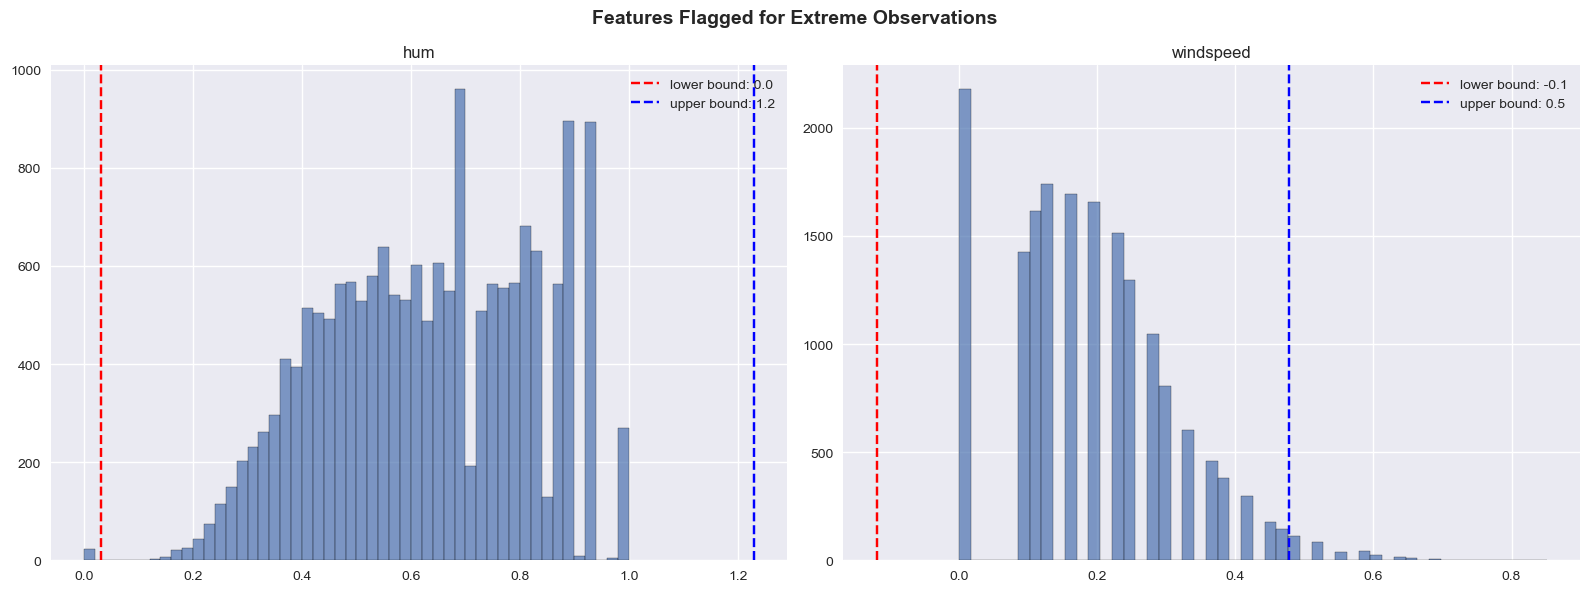

In [31]:
columns_with_extreme_obs = ['hum', 'windspeed']

# histograms for all features
f, ax = plt.subplots(1, 2, figsize=(16, 6))
ax = ax.flatten()

for i, col in enumerate(columns_with_extreme_obs):
    # calculate quartiles and IQR per column
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # plot histogram
    ax[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    ax[i].set_title(col)
    ax[i].set_xlabel('')

    # add vertical lines to the correct subplot
    ax[i].axvline(lower_bound, c='r', ls='--', label=f'lower bound: {lower_bound:.1f}')
    ax[i].axvline(upper_bound, c='b', ls='--', label=f'upper bound: {upper_bound:.1f}')

    ax[i].legend()

plt.suptitle('Features Flagged for Extreme Observations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Observations

| Column | % Outliers | Decision | Reasoning |
| :--- | :---: | :---: | :--- |
| hum | 0.14% | Keep | Outliers fall within expected normalized humidity range and reflect real environmental variation |
| windspeed | 1.83% | Keep | Extreme values are rare but valid; removing them would distort real-world weather patterns |

## Data Validation

In [32]:
print("=" * 50)
print("STEP 7: Final Validation")
print("=" * 50)

# Check for missing values
print("\n1. Missing Values:")
print(f"   X_train: {X_train.isnull().sum().sum()} missing")
print(f"   X_test:  {X_test.isnull().sum().sum()} missing")
print(f"   y_train: {y_train.isnull().sum()} missing")
print(f"   y_test:  {y_test.isnull().sum()} missing")

# Check for infinite values
print("\n2. Infinite Values:")
print(f"   X_train: {np.isinf(X_train).sum().sum()} infinite")
print(f"   X_test:  {np.isinf(X_test).sum().sum()} infinite")

# Final shapes
print("\n3. Final Shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")

print("\n All validation checks passed!")

STEP 7: Final Validation

1. Missing Values:
   X_train: 0 missing
   X_test:  0 missing
   y_train: 0 missing
   y_test:  0 missing

2. Infinite Values:
   X_train: 0 infinite
   X_test:  0 infinite

3. Final Shapes:
   X_train: (13903, 61)
   X_test:  (3476, 61)
   y_train: (13903,)
   y_test:  (3476,)

 All validation checks passed!


In [33]:
# import os
# import pickle

# # Create directory
# os.makedirs('../data/processed', exist_ok=True)

# # Save processed data
# X_train.to_csv('../data/processed/X_train.csv', index=False)
# X_train.to_csv('../data/processed/X_test.csv', index=False)
# y_train.to_csv('../data/processed/y_train.csv', index=False)
# y_test.to_csv('../data/processed/y_test.csv', index=False)

## Build Baseline Model

In [34]:
# train baseline model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [35]:
# predict
y_train_pred = baseline_model.predict(X_train)
y_test_pred = baseline_model.predict(X_test)

# evaluate
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

In [36]:
print('Baseline Model Performance (NO feature engineering)')
print('=' * 50)
print(f'{"Metric":<10} {"Train":>12} {"Test":>12}')
print('-' * 50)
print(f'{"R²":<10} {train_r2:>12.4f} {test_r2:>12.4f}')
print(f'{"RMSE":<10} {train_rmse:>12.4f} {test_rmse:>12.4f}')

Baseline Model Performance (NO feature engineering)
Metric            Train         Test
--------------------------------------------------
R²               0.6853       0.6893
RMSE           101.8258     100.7828


In [37]:
# save baseline performance for comparison
baseline_r2 = test_r2
baseline_rmse = test_rmse

print(f'\nBaseline to beat: R² = {baseline_r2:.4f}')


Baseline to beat: R² = 0.6893


## 7. Key Findings Summary

1. **Dataset:** 17,379 rows and 17 columns, no missing values, no duplicated samples
2. **Target(`cnt`):** no rows dropped for missing target
3. **Cleaning:** `casual`, `registered`, `instant`, `dteday` dropped for data leakage and little predictive power
4. **Train-Test Split:** 13,903 training samples and 3,476 test samples
5. **Missing Values:** data remains unchanged for no missing values
6. **Outliers:** `hum` and `windspeed` are extreme with % outlier being >0% than others